# 1. Data Loading and Initial Exploratory Data Analysis

## 1.1 Import Libraries and Configure Display Settings

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 1000)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1.2 Define Dataset Paths

In [2]:
# Resolve the project root so the notebook works across different systems
PROJECT_DIR = Path.cwd().resolve()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data" / "raw" / "elliptic_bitcoin_dataset"

classes_path = DATA_DIR / "elliptic_txs_classes.csv"
edges_path = DATA_DIR / "elliptic_txs_edgelist.csv"
features_path = DATA_DIR / "elliptic_txs_features.csv"

print("Classes file exists:", classes_path.exists())
print("Edges file exists:", edges_path.exists())
print("Features file exists:", features_path.exists())

print("\nDataset folder:", DATA_DIR.relative_to(PROJECT_DIR))

Classes file exists: True
Edges file exists: True
Features file exists: True

Dataset folder: data\raw\elliptic_bitcoin_dataset


## 1.3 Load Dataset Files

In [3]:
classes_df = pd.read_csv(classes_path)
edges_df = pd.read_csv(edges_path)
features_df = pd.read_csv(features_path, header=None)

print("Files loaded successfully.\n")
print("Classes shape:", classes_df.shape)
print("Edges shape:", edges_df.shape)
print("Features shape:", features_df.shape)

Files loaded successfully.

Classes shape: (203769, 2)
Edges shape: (234355, 2)
Features shape: (203769, 167)


The dataset contains 203,769 transactions, represented by 203,769 feature rows and 203,769 class labels, along with 234,355 transaction edges describing graph connectivity.

## 1.4 Inspect Raw Dataset Structure

In [4]:
print("Classes DataFrame:")
display(classes_df.head())

print("Edges DataFrame:")
display(edges_df.head())

print("Features DataFrame:")
display(features_df.head())

Classes DataFrame:


,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


Edges DataFrame:


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


Features DataFrame:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0.192405,-0.014659,-0.018849,-1.457921,-1.494024,-0.083459,-1.485939,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.121330,-0.110933,-0.075909,-0.111641,-1.159649,-1.160129,-1.373723,-1.353918,-0.295982,-1.403215,-0.975738,-0.975237,-0.168742,-0.263290,-0.186389,-0.250875,-1.015963,-1.016230,-0.968903,0.146997,1.366287,-0.464773,-1.116918,-1.116948,-0.216814,0.634272,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,-0.165054,-0.028741,-0.035391,-0.042955,-0.013282,

In [5]:
features_df = features_df.rename(columns={0: "txId", 1: "time_step"})

print("Renamed first two feature columns.")
display(features_df.head())

Renamed first two feature columns.


,txId,time_step,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0.192405,-0.014659,-0.018849,-1.457921,-1.494024,-0.083459,-1.485939,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.121330,-0.110933,-0.075909,-0.111641,-1.159649,-1.160129,-1.373723,-1.353918,-0.295982,-1.403215,-0.975738,-0.975237,-0.168742,-0.263290,-0.186389,-0.250875,-1.015963,-1.016230,-0.968903,0.146997,1.366287,-0.464773,-1.116918,-1.116948,-0.216814,0.634272,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,-0.165054,-0.028741,-0.035391,-0.042955

The feature matrix does not include a predefined header, so the first two columns are manually renamed to `txId` and `time_step`. This makes the data easier to interpret and supports later merging and temporal analysis.

## 1.5 Merge Features and Class Labels

In [6]:
merged_df = features_df.merge(classes_df, on="txId", how="left")

print("Merged DataFrame shape:", merged_df.shape)
display(merged_df[["txId", "time_step", "class"]].head())

Merged DataFrame shape: (203769, 168)


,txId,time_step,class
0,230425980,1,unknown
1,5530458,1,unknown
2,232022460,1,unknown
3,232438397,1,2
4,230460314,1,unknown


In [7]:
print("Raw class distribution:")
print(merged_df["class"].value_counts(dropna=False))

Raw class distribution:
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64


The merged dataset contains three class categories: `1`, `2`, and `unknown`. In the Elliptic dataset, class `1` represents illicit transactions, class `2` represents licit transactions, and `unknown` indicates unlabeled transactions. Since supervised classification requires known labels, the `unknown` category will be excluded from the main modeling dataset.

## 1.6 Label Cleaning and Binary Target Definition

In [8]:
# Make class values consistent as strings first
merged_df["class"] = merged_df["class"].astype(str).str.strip()

# Keep only labeled transactions
filtered_df = merged_df[merged_df["class"].isin(["1", "2"])].copy()

# Create binary target
# 1 = illicit
# 0 = licit
filtered_df["label"] = filtered_df["class"].map({"1": 1, "2": 0})

print("Filtered labeled dataset shape:", filtered_df.shape)
print("\nBinary label distribution:")
print(filtered_df["label"].value_counts())

Filtered labeled dataset shape: (46564, 169)

Binary label distribution:
label
0    42019
1     4545
Name: count, dtype: int64


After removing unlabeled transactions, the supervised dataset contains only licit and illicit examples. The resulting class distribution is clearly imbalanced, with licit transactions substantially outnumbering illicit ones. This confirms that later modeling and evaluation must be handled as an imbalanced classification problem.

In [9]:
display(filtered_df[["txId", "time_step", "class", "label"]].head())

print("\nLabel meaning:")
print("0 = licit")
print("1 = illicit")

,txId,time_step,class,label
3,232438397,1,2,0
9,232029206,1,2,0
10,232344069,1,2,0
11,27553029,1,2,0
16,3881097,1,2,0



Label meaning:
0 = licit
1 = illicit


## 1.7 Missing Value Checks and Data Quality Review

In [10]:
print("Missing values in classes_df:")
print(classes_df.isnull().sum())

print("\nMissing values in edges_df:")
print(edges_df.isnull().sum())

print("\nTop missing values in filtered_df:")
missing_summary = filtered_df.isnull().sum()
print(missing_summary[missing_summary > 0].sort_values(ascending=False).head(20))

Missing values in classes_df:
txId     0
class    0
dtype: int64

Missing values in edges_df:
txId1    0
txId2    0
dtype: int64

Top missing values in filtered_df:
Series([], dtype: int64)


The missing value analysis provides an initial indication of data quality. Since graph-based and machine learning models can be sensitive to incomplete inputs, confirming the absence or limited presence of missing data is an important preprocessing step.

## 1.8 Descriptive Statistics

In [11]:
print("Descriptive statistics for numeric columns:")
display(filtered_df.describe())

Descriptive statistics for numeric columns:


,txId,time_step,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,label
count,4.656400e+04,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000,46564.000000
mean,1.745082e+08,24.599046,-0.052645,0.159103,0.148974,0.172216,0.028651,0.184429,-0.015381,-0.077488,-0.059497,0.099852,-0.072692,-0.184983,-0.157396,0.030979,-0.013107,0.050150,-0.057187,-0.088547,-0.085497,-0.236332,-0.230742,0.360059,0.428964,0.267698,0.429306,-0.148598,-0.142262,0.360049,0.428945,0.267697,0.429298,-0.148792,-0.142450,0.081825,0.101714,0.070861,0.084880,-0.000653,-0.000865,0.289370,0.356418,0.249281,0.324503,-0.097518,-0.114511,0.285130,0.348326,0.324640,0.316539,-0.096156,-0.112464,0.546780,0.871701,0.675015,0.725261,0.030801,0.022748,0.104502,0.507747,0.475737,0.462539,-0.013810,-0.011907,0.104493,0.507715,0.475708,0.462525,-0.013985,-0.012152,0.014078,0.088285,0.048994,0.036785,0.177524,0.175826,0.009262,0.400804,0.380809,0.365306,0.068294,0.063589,0.081277,0.398981,0.373683,0.372812,0.059073,0.054584,0.107112,0.400321,0.391397,0.357064,0.234907,0.236516,0.036309,0.161245,0.214865,0.080174,-0.100823,-0.094096,0.031320,0.050981,0.110332,0.046256,-0.071959,-0.076668,0.241219,0.360839,0.240319,0.291714,0.008257,0.009523,-0.007188,0.279092,0.440640,0.145991,0.026765,0.027212,0.056460,0.189492,0.173082,0.097888,0.037589,0.042371,0.249741,0.369271,0.249595,0.325597,-0.013047,-0.011725,-0.018680,0

In [12]:
class_percentages = filtered_df["label"].value_counts(normalize=True).sort_index() * 100

print("Class percentages:")
print(f"Licit (0): {class_percentages[0]:.2f}%")
print(f"Illicit (1): {class_percentages[1]:.2f}%")

Class percentages:
Licit (0): 90.24%
Illicit (1): 9.76%


The percentage breakdown shows that illicit transactions form only a small portion of the labeled dataset. This level of imbalance is typical in fraud detection settings and reinforces the need for suitable evaluation metrics such as precision, recall, F1-score, and PR-AUC.

In [13]:
feature_cols = [col for col in filtered_df.columns if col not in ["txId", "time_step", "class", "label"]]

print("Number of feature columns:", len(feature_cols))
display(filtered_df[feature_cols[:10]].describe().T)

Number of feature columns: 165


,count,mean,std,min,25%,50%,75%,max
2,46564.0,-0.052645,0.702554,-0.172982,-0.172683,-0.170652,-0.141446,39.786756
3,46564.0,0.159103,1.544040,-0.210553,-0.162140,-0.113851,0.016948,73.595052
4,46564.0,0.148974,1.063158,-1.756361,-1.201369,0.463609,1.018602,2.683580
5,46564.0,0.172216,1.600931,-0.121970,-0.121970,-0.121970,0.028105,49.027598
6,46564.0,0.028651,1.729706,-0.063725,-0.043875,-0.043875,-0.043875,260.090707
7,46564.0,0.184429,1.589399,-0.113002,-0.113002,-0.113002,-0.029140,54.565178
8,46564.0,-0.015381,0.577378,-0.061584,-0.061584,-0.061584,-0.061584,44.365651
9,46564.0,-0.077488,0.588778,-0.163646,-0.163614,-0.163383,-0.158465,40.721063
10,46564.0,-0.059497,0.667889,-0.169460,-0.169230,-0.167581,-0.145476,40.142250
11,46564.0,0.099852,1.864245,-0.049707,-0.049707,-0.049707,-0.043681,189.186944


The selected feature summary shows that the dataset contains a large number of anonymized numerical variables. Although the semantic meaning of each feature is not directly provided, their distributions and ranges still offer useful information for preprocessing and model development.

In [14]:
processed_dir = PROJECT_DIR / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

filtered_output_path = processed_dir / "elliptic_labeled_transactions.csv"
filtered_df.to_csv(filtered_output_path, index=False)

print("Saved cleaned labeled dataset to:")
print(filtered_output_path.relative_to(PROJECT_DIR))

Saved cleaned labeled dataset to:
data\processed\elliptic_labeled_transactions.csv


## 1.9 Exploratory Data Analysis

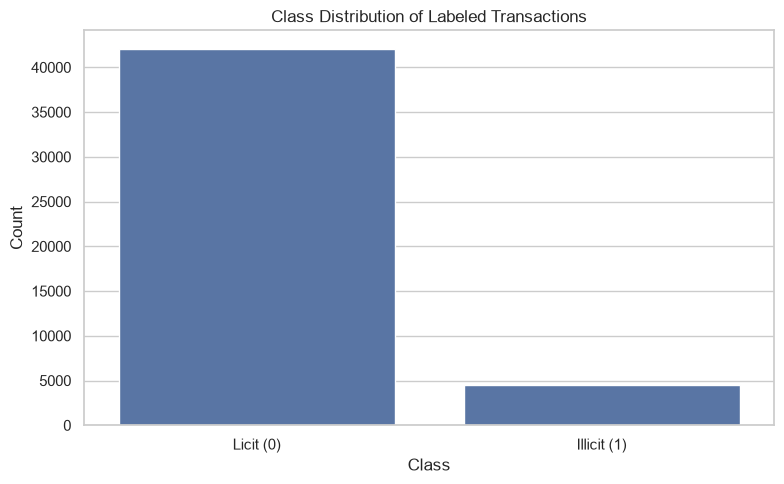

In [15]:
label_counts = filtered_df["label"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=["Licit (0)", "Illicit (1)"], y=label_counts.values)
plt.title("Class Distribution of Labeled Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The class distribution plot clearly shows that licit transactions dominate the labeled subset. This imbalance is expected in fraud detection datasets and suggests that accuracy-based evaluation would be misleading.

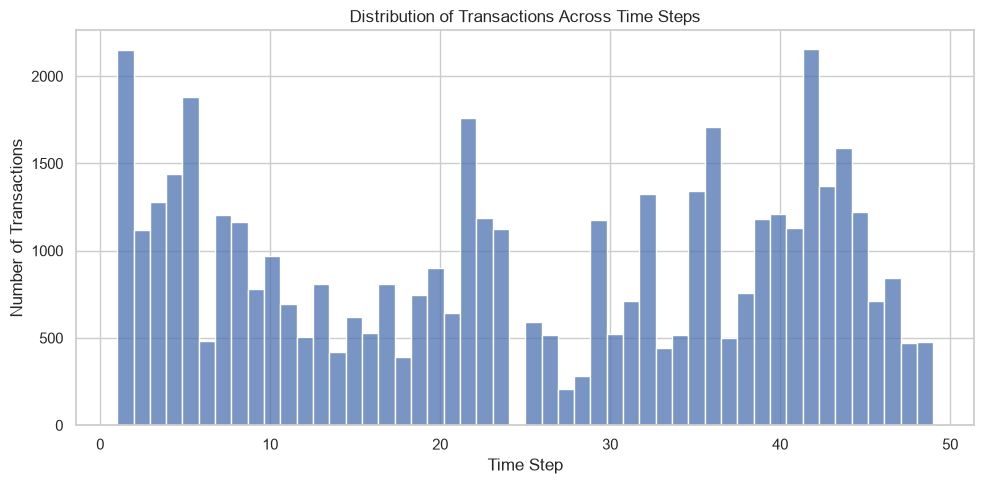

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(filtered_df["time_step"], bins=50, kde=False)
plt.title("Distribution of Transactions Across Time Steps")
plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

The temporal distribution shows how labeled transactions are spread across the available time steps. This is useful for identifying whether the dataset is temporally concentrated or reasonably distributed over time.

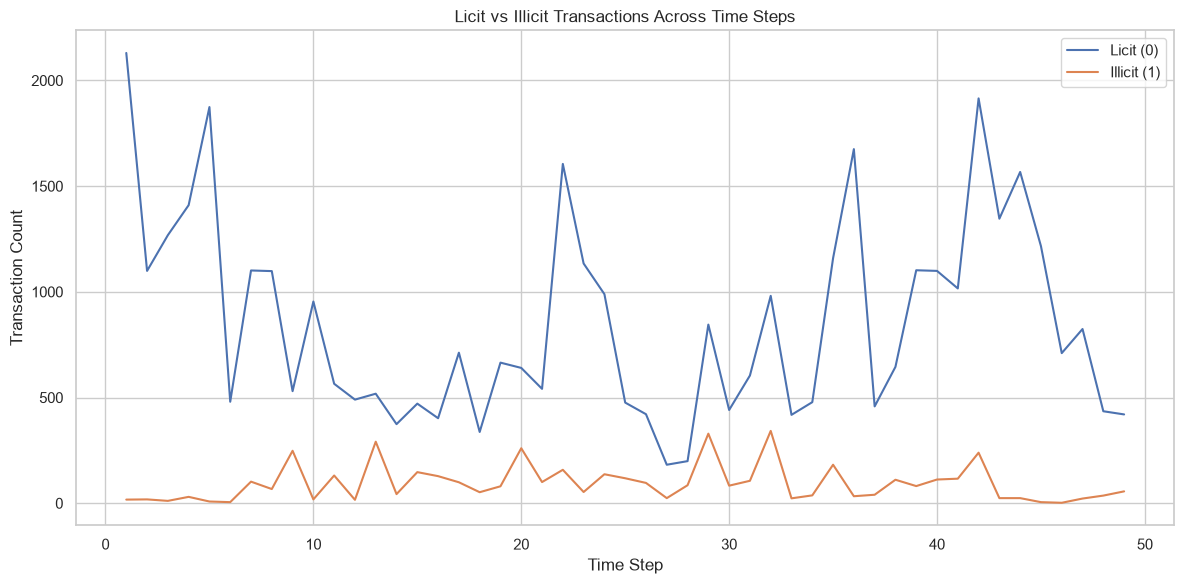

In [17]:
time_class_counts = filtered_df.groupby(["time_step", "label"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
plt.plot(time_class_counts.index, time_class_counts[0], label="Licit (0)")
plt.plot(time_class_counts.index, time_class_counts[1], label="Illicit (1)")
plt.title("Licit vs Illicit Transactions Across Time Steps")
plt.xlabel("Time Step")
plt.ylabel("Transaction Count")
plt.legend()
plt.tight_layout()
plt.show()

Comparing licit and illicit transaction counts across time steps helps reveal whether fraudulent activity follows similar or different temporal patterns from normal transactions. This may later support temporal interpretation of model behavior.

## 1.10 Initial Graph Summary

In [18]:
num_edges = len(edges_df)
unique_nodes_in_edges = len(set(edges_df["txId1"]).union(set(edges_df["txId2"])))

print("Graph Summary")
print("-------------")
print("Number of edges:", num_edges)
print("Number of unique nodes appearing in edge list:", unique_nodes_in_edges)

Graph Summary
-------------
Number of edges: 234355
Number of unique nodes appearing in edge list: 203769


The graph summary confirms that the Elliptic dataset contains a large transaction network with substantial connectivity. This supports the use of graph neural networks such as GCN and GAT in later stages of the project.

In [19]:
labeled_nodes = set(filtered_df["txId"])
edge_nodes = set(edges_df["txId1"]).union(set(edges_df["txId2"]))

labeled_nodes_in_graph = len(labeled_nodes.intersection(edge_nodes))

print("Number of labeled nodes:", len(labeled_nodes))
print("Number of labeled nodes that appear in the graph:", labeled_nodes_in_graph)

Number of labeled nodes: 46564
Number of labeled nodes that appear in the graph: 46564


This check shows how many labeled transactions are actually represented in the graph structure. A strong overlap between labeled nodes and graph-connected nodes is important for meaningful graph-based learning.

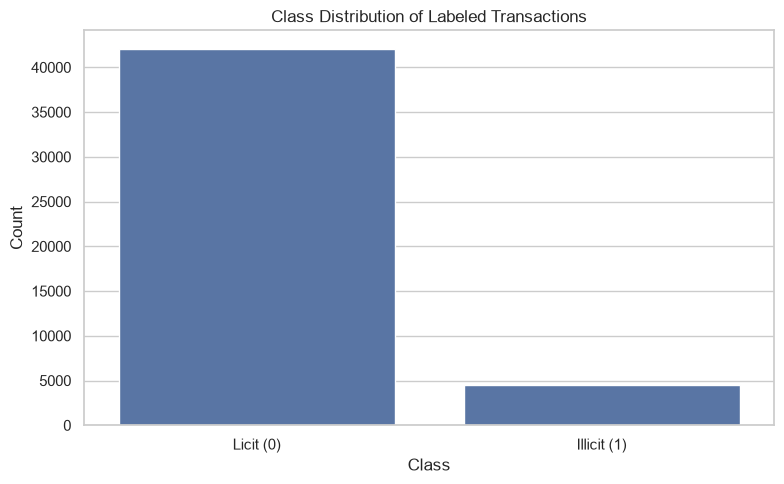

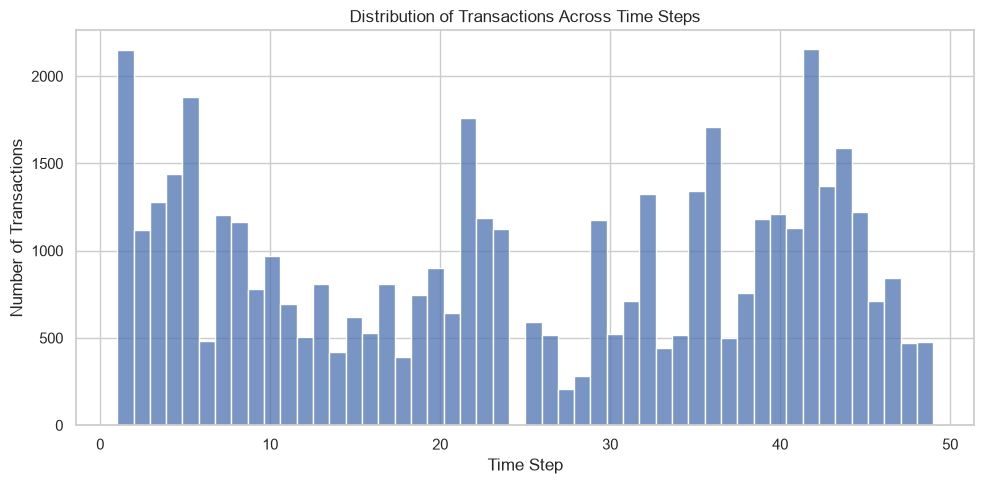

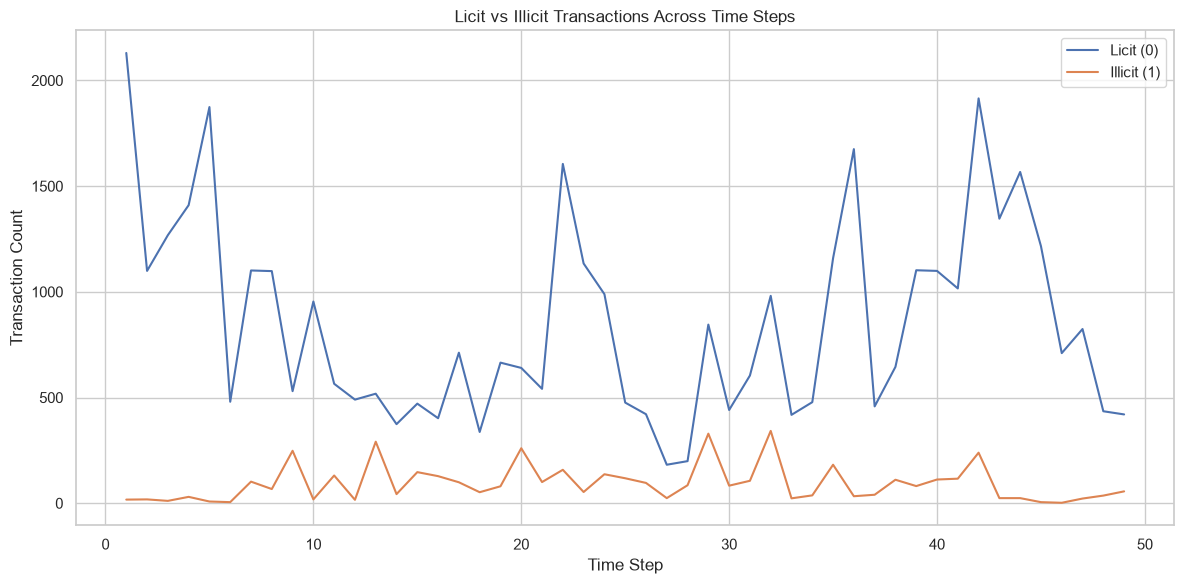

Figures saved to: figures


In [20]:
figures_dir = PROJECT_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Class distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=["Licit (0)", "Illicit (1)"], y=label_counts.values)
plt.title("Class Distribution of Labeled Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(figures_dir / "class_distribution.png", dpi=300)
plt.show()

# Time step distribution
plt.figure(figsize=(10, 5))
sns.histplot(filtered_df["time_step"], bins=50, kde=False)
plt.title("Distribution of Transactions Across Time Steps")
plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig(figures_dir / "time_step_distribution.png", dpi=300)
plt.show()

# Licit vs illicit by time step
plt.figure(figsize=(12, 6))
plt.plot(time_class_counts.index, time_class_counts[0], label="Licit (0)")
plt.plot(time_class_counts.index, time_class_counts[1], label="Illicit (1)")
plt.title("Licit vs Illicit Transactions Across Time Steps")
plt.xlabel("Time Step")
plt.ylabel("Transaction Count")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "licit_vs_illicit_by_time.png", dpi=300)
plt.show()

print("Figures saved to:", figures_dir.relative_to(PROJECT_DIR))